Experiment objective

Implement and compare RNN, LSTM, and GRU models for binary sequence classification using the IMDb 50K movie-review dataset and evaluate them using accuracy, precision, recall, F1-score, confusion matrices, training time, and parameter count.

In [2]:
# Install the libraries required for dataset downloading,
# data manipulation, deep learning, evaluation, and visualization.

!pip install -q kagglehub tensorflow scikit-learn seaborn pandas matplotlib

In [3]:
# Import operating-system utilities for handling dataset file paths.
import os

# Import regular expressions for text cleaning.
import re

# Import time to measure model training duration.
import time

# Import random to control random operations.
import random

# Import NumPy for numerical operations.
import numpy as np

# Import Pandas for creating and manipulating dataframes.
import pandas as pd

# Import Matplotlib for plotting graphs.
import matplotlib.pyplot as plt

# Import Seaborn for statistical visualizations.
import seaborn as sns

# Import TensorFlow for building and training neural networks.
import tensorflow as tf

# Import functions for splitting the dataset.
from sklearn.model_selection import train_test_split

# Import evaluation metrics for binary classification.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

# Import the Keras tokenizer for converting text into integer sequences.
from tensorflow.keras.preprocessing.text import Tokenizer

# Import padding utility to make all sequences equal in length.
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Import the Sequential model API.
from tensorflow.keras.models import Sequential

# Import layers required for the three models.
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
    Dropout
)

# Import EarlyStopping to stop training when validation performance stops improving.
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")

In [5]:
# Dataset: IMDB Movie Review Dataset(kaggle)
import kagglehub

path = kagglehub.dataset_download(
    "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"
)

print("Dataset downloaded to:")
print(path)

print("\nFiles:")
print(os.listdir(path))

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset downloaded to:
/kaggle/input/imdb-dataset-of-50k-movie-reviews

Files:
['IMDB Dataset.csv']


In [6]:
# Load  Dataset:
file_path = os.path.join(
    path,
    "IMDB Dataset.csv"
)

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
# Display basic information about the dataset,
# including column names, data types, and non-null values.
print("Dataset Information")
print("=" * 60)
df.info()

# Display the number of missing values in each column.
print("\nMissing Values:")
print(df.isnull().sum())

# Count duplicate reviews.
# Duplicate reviews may cause data leakage if the same review
# appears in both training and testing sets.
print("\nDuplicate Reviews:")
print(df["review"].duplicated().sum())

# Display the number of positive and negative reviews.
# This helps us understand the class distribution.
print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

Dataset Information
Number of reviews: 50000
Number of columns: 2

Columns:
['review', 'sentiment']

Missing values:
review       0
sentiment    0
dtype: int64

Duplicate reviews:
418

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


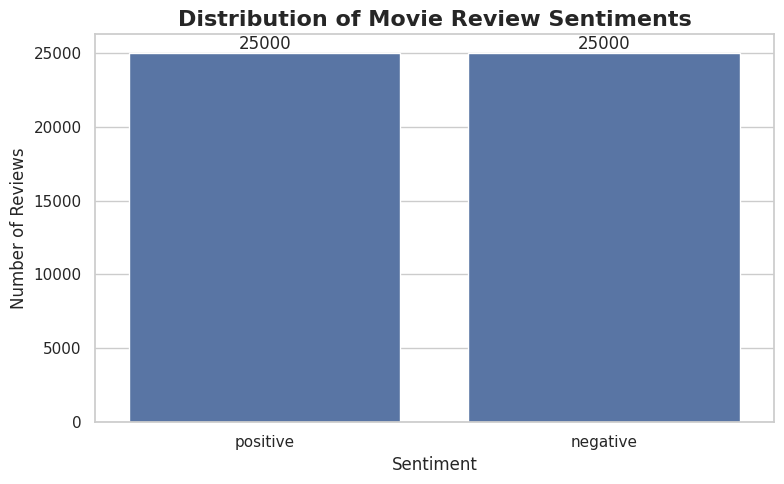

In [8]:
# Visulization:Class Distribution
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="sentiment"
)

plt.title(
    "Distribution of Movie Review Sentiments",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [9]:
# Define a function to clean individual movie reviews.
def clean_text(text):

    # Convert all characters to lowercase.
    # This reduces the number of unique word representations.
    text = text.lower()

    # Remove HTML line-break tags such as <br />.
    # These tags are present in some IMDb reviews.
    text = re.sub(r"<br\s*/?>", " ", text)

    # Remove non-alphabetic characters.
    # This keeps the text simpler for tokenization.
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Replace multiple spaces with a single space.
    text = re.sub(r"\s+", " ", text).strip()

    # Return the cleaned review.
    return text


# Apply the clean_text function to every review in the dataset.
# The cleaned reviews are stored in a new column.
df["clean_review"] = df["review"].apply(clean_text)

# Display the original and cleaned versions of one review.
# This allows us to verify that preprocessing worked correctly.
print("Original Review:")
print(df["review"].iloc[0])

print("\nCleaned Review:")
print(df["clean_review"].iloc[0])

In [10]:
# Label Encoding
df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

print(df[["sentiment", "label"]].head())

  sentiment  label
0  positive      1
1  positive      1
2  positive      1
3  negative      0
4  positive      1


In [11]:
# Analyze review length
df["review_length"] = df["clean_review"].apply(
    lambda x: len(x.split())
)

print(df["review_length"].describe())

count    50000.000000
mean       234.187100
std        173.516096
min          6.000000
25%        128.000000
50%        176.000000
75%        284.000000
max       2494.000000
Name: review_length, dtype: float64


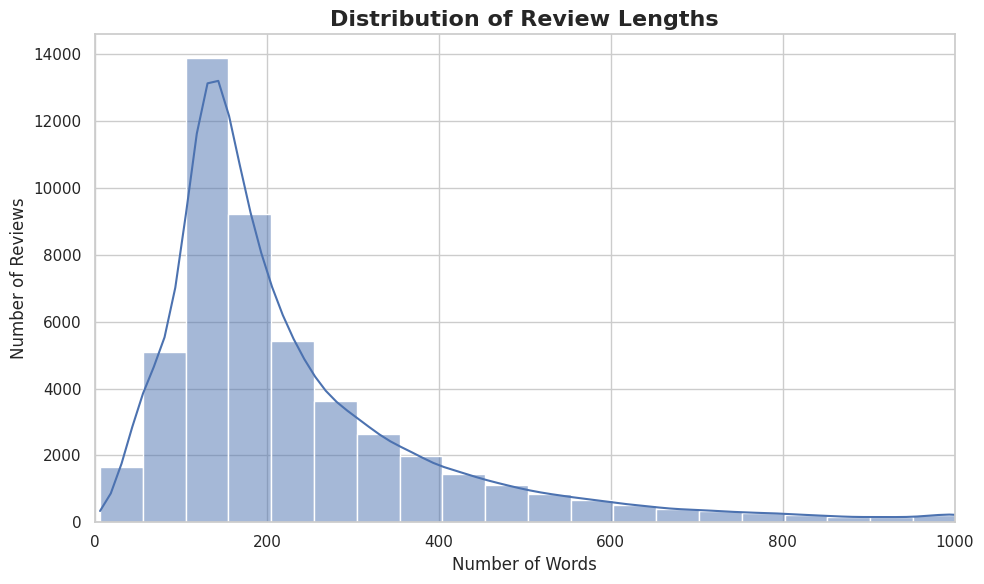

In [12]:
# Visualization: Review length distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="review_length",
    bins=50,
    kde=True
)

plt.title(
    "Distribution of Review Lengths",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

# Ignore extremely long reviews in visualization
plt.xlim(0, 1000)

plt.tight_layout()
plt.show()

In [13]:
# Train/Test Split:
# Training : 80%
# Testing  : 10%
# Validation : 10%

X = df["clean_review"].values
y = df["label"].values
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=SEED,
    stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.111111,
    random_state=SEED,
    stratify=y_train
)
print("Training samples   :", len(X_train))
print("Validation samples :", len(X_val))
print("Testing samples    :", len(X_test))

Training samples   : 40000
Validation samples : 5000
Testing samples    : 5000


In [14]:
#Tokenizer:
# Set the maximum number of words to retain in the vocabulary.
# Only the most frequent words will be assigned individual indices.
VOCAB_SIZE = 20000

# Set the maximum number of tokens in each review sequence.
# Reviews longer than this will be truncated.
# Shorter reviews will be padded.
MAX_LENGTH = 250

# Set the dimensionality of the word embeddings.
EMBEDDING_DIM = 128

# Set the number of hidden units in each recurrent layer.
RNN_UNITS = 64

# Set the dropout rate to reduce overfitting.
DROPOUT_RATE = 0.3

# Set the batch size used during training.
BATCH_SIZE = 64

# Set the maximum number of training epochs.
EPOCHS = 5

# Set the learning rate for the Adam optimizer.
LEARNING_RATE = 0.
# Create a tokenizer that keeps the most frequent words
# and assigns an OOV token to unknown words.
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

# Fit the tokenizer only on the training reviews.
# This prevents information from validation or test data
# from influencing the vocabulary.
tokenizer.fit_on_texts(X_train)

# Display the total number of unique words discovered.
print("Total words in tokenizer:", len(tokenizer.word_index))
# Convert training reviews into sequences of integer word IDs.
X_train_seq = tokenizer.texts_to_sequences(X_train)

# Convert validation reviews into integer sequences.
X_val_seq = tokenizer.texts_to_sequences(X_val)

# Convert testing reviews into integer sequences.
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Display an example of a tokenized review.
print("Example tokenized review:")
print(X_train_seq[0][:20])

In [15]:
# Pad or truncate training sequences to a fixed length.
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

# Pad or truncate validation sequences to the same fixed length.
X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

# Pad or truncate testing sequences to the same fixed length.
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

# Display the shapes of the resulting arrays.
# Each review should now contain exactly MAX_LENGTH tokens.
print("Training shape   :", X_train_pad.shape)
print("Validation shape :", X_val_pad.shape)
print("Testing shape    :", X_test_pad.shape)

Training shape   : (40000, 250)
Validation shape : (5000, 250)
Testing shape    : (5000, 250)


In [16]:
# Define common hyperparameters:
EMBEDDING_DIM = 128
RNN_UNITS = 64
DROPOUT_RATE = 0.3

BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 0.001

In [17]:
# Define a function that creates a Simple RNN model.
def build_rnn():

    # Create a sequential neural-network architecture.
    model = Sequential([

        # Define the input shape as a sequence of MAX_LENGTH integer tokens.
        Input(shape=(MAX_LENGTH,)),

        # Convert each integer word ID into a dense embedding vector.
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM
        ),

        # Process the sequence using a basic Simple RNN layer.
        # The final hidden state is used for classification.
        SimpleRNN(
            RNN_UNITS
        ),

        # Randomly deactivate a fraction of neurons during training
        # to reduce overfitting.
        Dropout(
            DROPOUT_RATE
        ),

        # Produce one probability for binary classification.
        # Sigmoid outputs a value between 0 and 1.
        Dense(
            1,
            activation="sigmoid"
        )
    ])

    # Compile the model using the Adam optimizer.
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Return the compiled model.
    return model

In [18]:
# Define a function that creates an LSTM model.
def build_lstm():

    # Create a sequential neural-network architecture.
    model = Sequential([

        # Define the input shape as a sequence of MAX_LENGTH tokens.
        Input(shape=(MAX_LENGTH,)),

        # Convert word IDs into dense embedding vectors.
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM
        ),

        # Process the sequence using an LSTM layer.
        # LSTM uses memory cells and gates to learn long-term dependencies.
        LSTM(
            RNN_UNITS
        ),

        # Apply dropout to reduce overfitting.
        Dropout(
            DROPOUT_RATE
        ),

        # Produce a probability for the positive class.
        Dense(
            1,
            activation="sigmoid"
        )
    ])

    # Compile the model using the same optimizer and loss
    # as the RNN model for a fair comparison.
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Return the compiled model.
    return model

In [19]:
# Define a function that creates a GRU model.
def build_gru():

    # Create a sequential neural-network architecture.
    model = Sequential([

        # Define the input shape as a sequence of MAX_LENGTH tokens.
        Input(shape=(MAX_LENGTH,)),

        # Convert word IDs into dense embedding vectors.
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM
        ),

        # Process the sequence using a GRU layer.
        # GRU uses update and reset gates to control information flow.
        GRU(
            RNN_UNITS
        ),

        # Apply dropout to reduce overfitting.
        Dropout(
            DROPOUT_RATE
        ),

        # Produce a probability for binary classification.
        Dense(
            1,
            activation="sigmoid"
        )
    ])

    # Compile the model using the same optimizer and loss
    # as the RNN and LSTM models.
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Return the compiled model.
    return model

In [20]:
# Create All Models:
models = {
    "RNN": build_rnn(),
    "LSTM": build_lstm(),
    "GRU": build_gru()
}

In [21]:
for name, model in models.items():

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)

    model.summary()



RNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,572,417 (9.81 MB)

 Trainable params: 2,572,417 (9.81 MB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 250, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,597,313 (9.91 MB)

 Trainable params: 2,597,313 (9.91 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
parameter_results = []

for name, model in models.items():

    parameter_results.append({
        "Model": name,
        "Parameters": model.count_params()
    })

parameter_df = pd.DataFrame(
    parameter_results
)

parameter_df

,Model,Parameters
0,RNN,2572417
1,LSTM,2609473
2,GRU,2597313


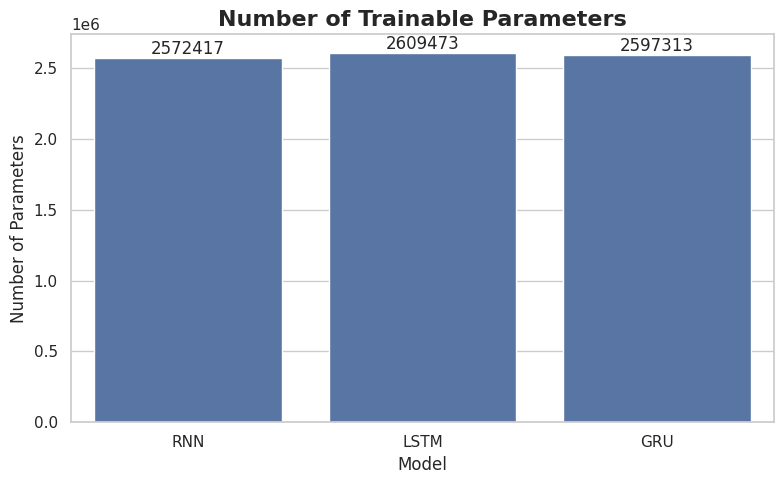

In [23]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=parameter_df,
    x="Model",
    y="Parameters"
)

plt.title(
    "Number of Trainable Parameters",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Number of Parameters")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()



TRAINING RNN
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 121ms/step - accuracy: 0.5021 - loss: 0.6990 - val_accuracy: 0.5088 - val_loss: 0.6930
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 122ms/step - accuracy: 0.5917 - loss: 0.6437 - val_accuracy: 0.5052 - val_loss: 0.7425
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 123ms/step - accuracy: 0.5773 - loss: 0.6641 - val_accuracy: 0.5048 - val_loss: 0.7193

RNN training time: 241.44 seconds


TRAINING LSTM
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 178s 282ms/step - accuracy: 0.5332 - loss: 0.6862 - val_accuracy: 0.5406 - val_loss: 0.6786
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 174s 279ms/step - accuracy: 0.6546 - loss: 0.6073 - val_accuracy: 0.7472 - val_loss: 0.5492
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 176s 282ms/step - accuracy: 0.8042 - loss: 0.4780 - val_accuracy: 0.5122 - val_loss: 0.8245
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 205s 286ms/step - accuracy: 0.6089 - loss: 0.6242 - val_accuracy: 0.7712 - val_loss: 0.5531

LSTM training time:

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

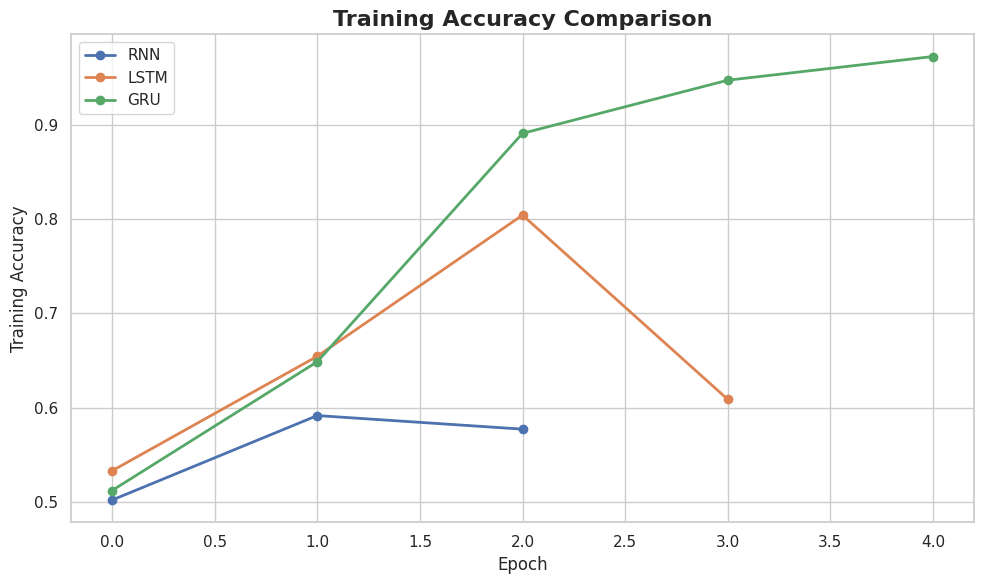

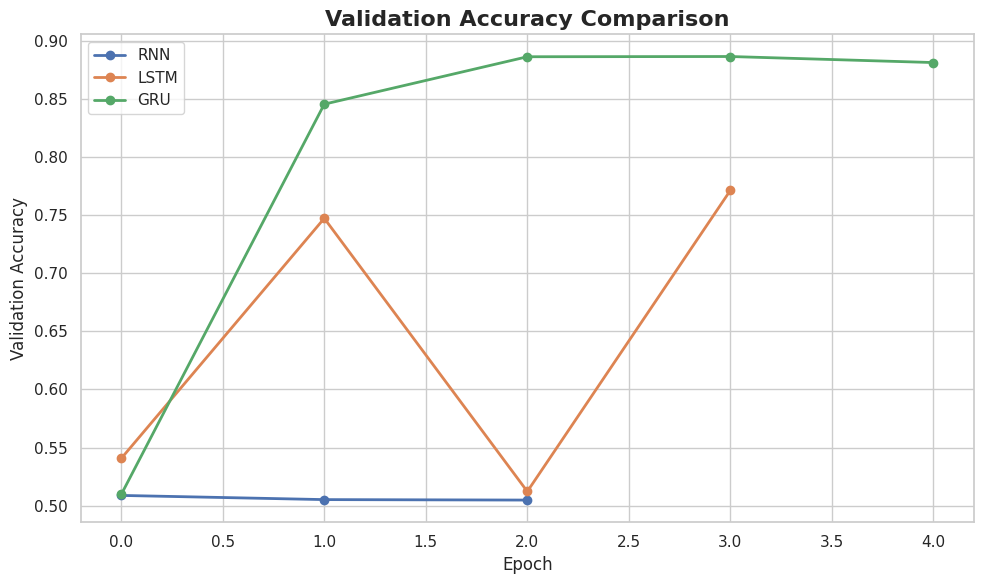

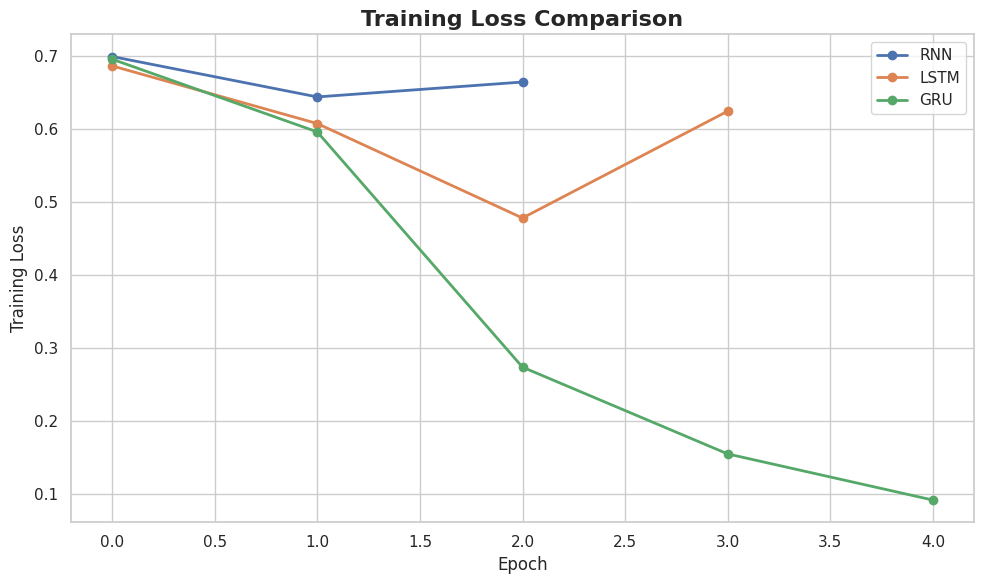

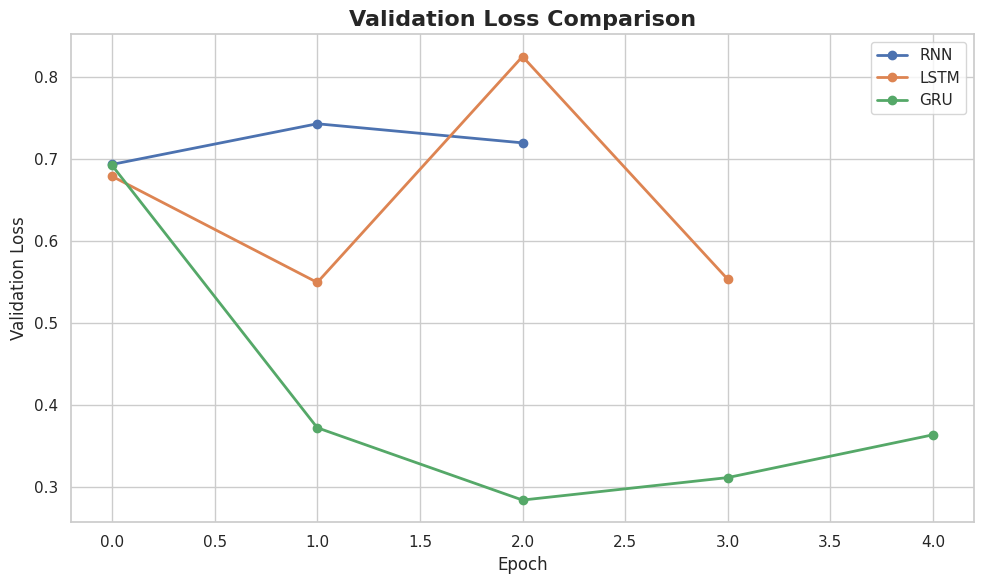

In [24]:
# Create an EarlyStopping callback.
# Training stops if validation loss does not improve for two consecutive epochs.
# restore_best_weights=True restores the weights from the best validation epoch.
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

# Create dictionaries to store training histories and training times.
histories = {}
training_times = {}
# Train each model using the same training and validation data.
# Keeping the dataset, optimizer, batch size, epochs, and other settings
# consistent makes the comparison more meaningful.

for name, model in models.items():

    # Print a heading indicating which model is being trained.
    print("\n")
    print("=" * 70)
    print(f"TRAINING {name}")
    print("=" * 70)

    # Record the starting time before training.
    start_time = time.time()

    # Train the current model.
    history = model.fit(
        X_train_pad,
        y_train,

        # Use validation data to monitor generalization during training.
        validation_data=(
            X_val_pad,
            y_val
        ),

        # Set the maximum number of epochs.
        epochs=EPOCHS,

        # Set the number of samples processed in each batch.
        batch_size=BATCH_SIZE,

        # Use early stopping to reduce unnecessary training.
        callbacks=[
            early_stopping
        ],

        # Display training progress.
        verbose=1
    )

    # Record the ending time after training.
    end_time = time.time()

    # Calculate and store the total training duration.
    training_times[name] = end_time - start_time

    # Store the training history for later visualization.
    histories[name] = history

    # Display the training time for the current model.
    print(
        f"\n{name} training time: "
        f"{training_times[name]:.2f} seconds"
    )
    # Display the number of epochs completed by each model.
# Early stopping may cause a model to train for fewer than EPOCHS.
for name, history in histories.items():

    # The length of the accuracy list equals the number of completed epochs.
    completed_epochs = len(history.history["accuracy"])

    print(
        f"{name}: {completed_epochs} epochs completed"
    )

In [26]:
results = []
predictions = {}
probabilities = {}

for name, model in models.items():

    print("\n")
    print("=" * 70)
    print(f"EVALUATING {name}")
    print("=" * 70)

    # Probability predictions
    y_prob = model.predict(
        X_test_pad,
        verbose=0
    ).ravel()

    # Convert probabilities to class labels
    y_pred = (y_prob >= 0.5).astype(int)

    probabilities[name] = y_prob
    predictions[name] = y_pred

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time": training_times[name],
        "Parameters": model.count_params()
    })
results_df = pd.DataFrame(results)

results_df.round(4)



EVALUATING RNN


EVALUATING LSTM


EVALUATING GRU


,Model,Accuracy,Precision,Recall,F1 Score,Training Time,Parameters
0,RNN,0.5122,0.5157,0.4008,0.4510,241.4445,2572417
1,LSTM,0.7460,0.7079,0.8376,0.7673,733.0795,2609473
2,GRU,0.8814,0.8549,0.9188,0.8857,954.4171,2597313


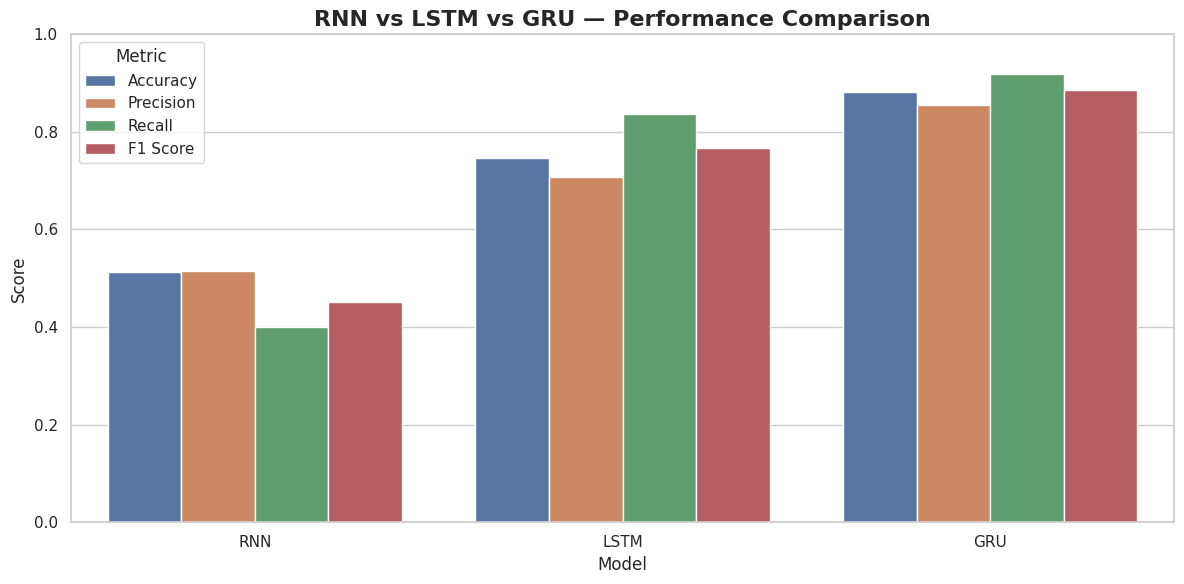

In [27]:
metric_df = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
]

metric_long = metric_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=metric_long,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title(
    "RNN vs LSTM vs GRU — Performance Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.legend(
    title="Metric"
)

plt.tight_layout()
plt.show()

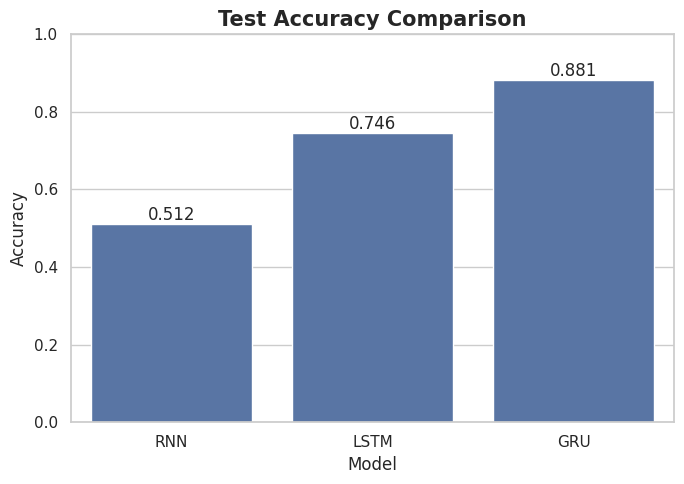

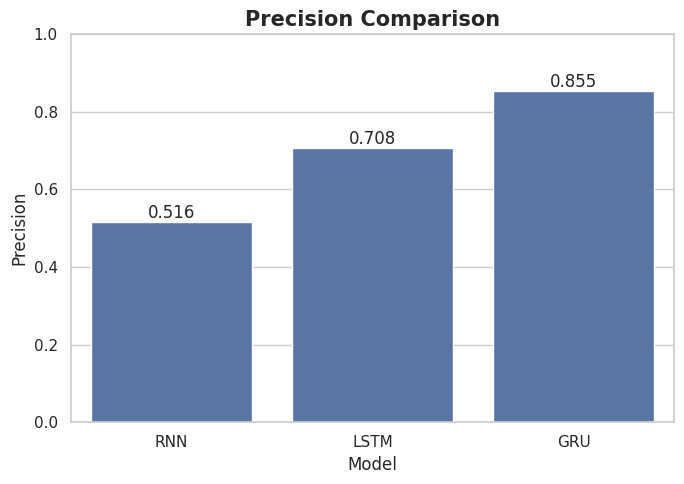

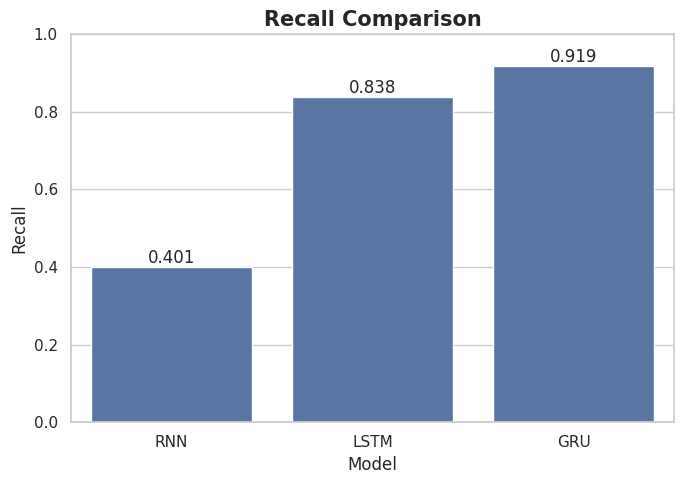

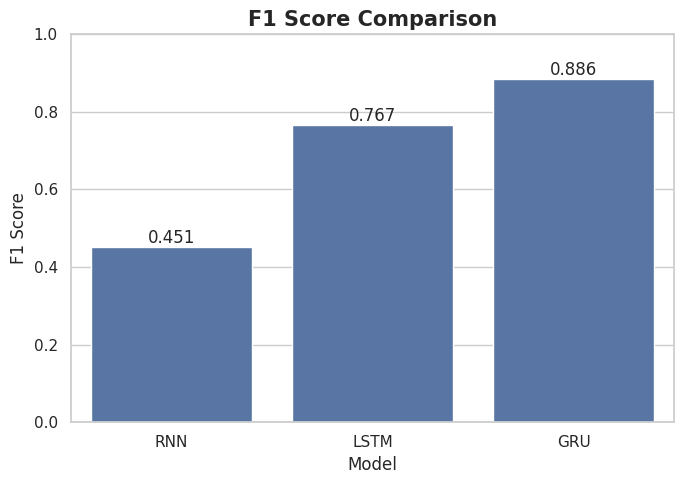

In [30]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Test Accuracy Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f"
    )

plt.tight_layout()
plt.show()
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=results_df,
    x="Model",
    y="Precision"
)

plt.title(
    "Precision Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Precision")

plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f"
    )

plt.tight_layout()
plt.show()
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=results_df,
    x="Model",
    y="Recall"
)

plt.title(
    "Recall Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Recall")

plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f"
    )

plt.tight_layout()
plt.show()
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score"
)

plt.title(
    "F1 Score Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f"
    )

plt.tight_layout()
plt.show()

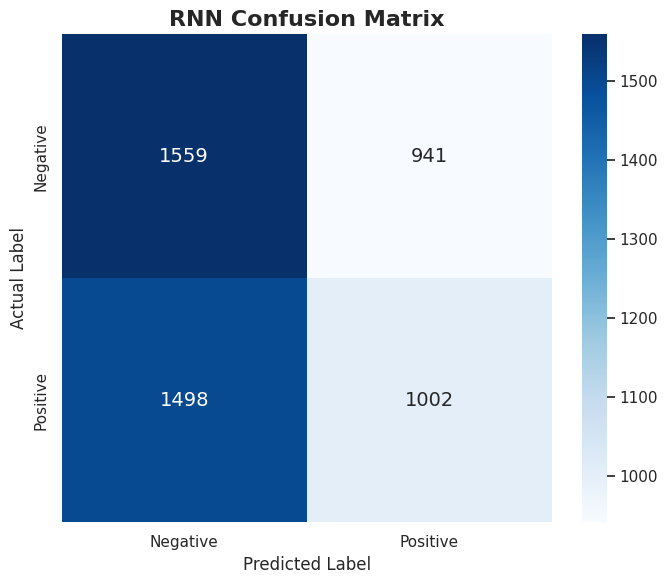

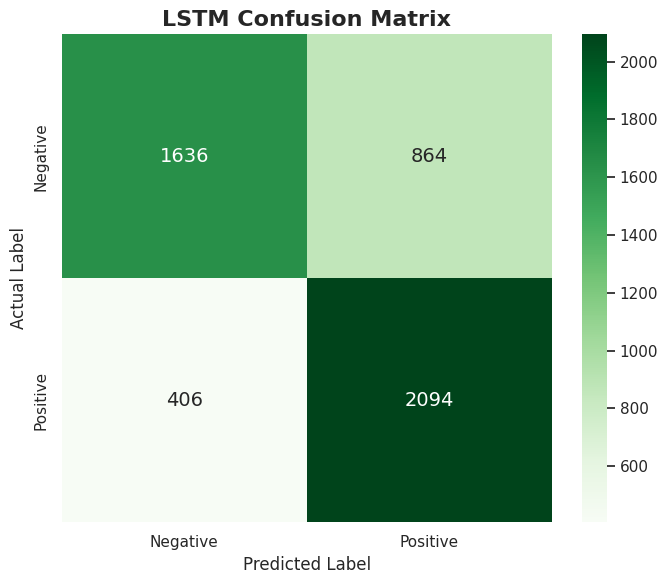

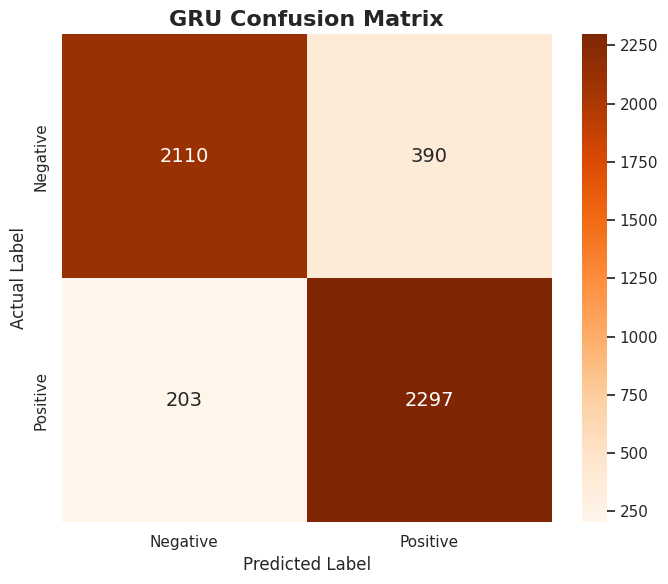

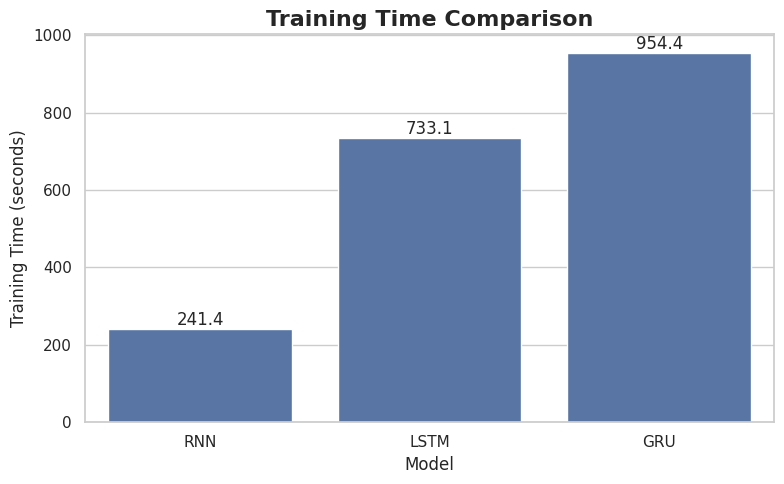

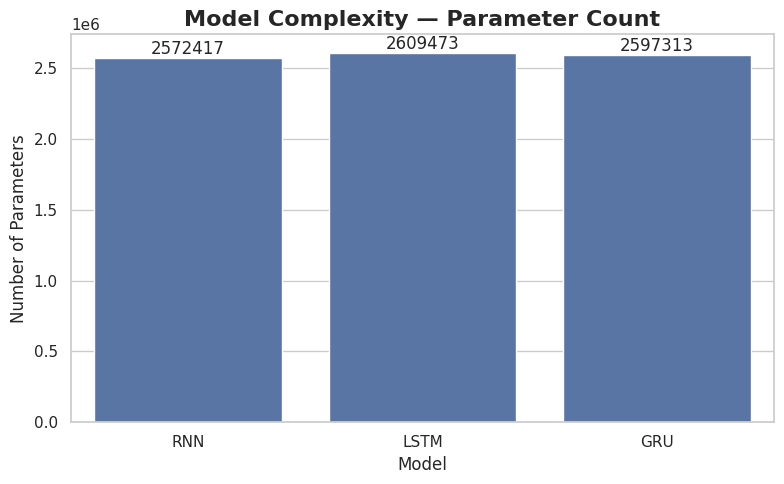



RNN
              precision    recall  f1-score   support

    Negative     0.5100    0.6236    0.5611      2500
    Positive     0.5157    0.4008    0.4510      2500

    accuracy                         0.5122      5000
   macro avg     0.5128    0.5122    0.5061      5000
weighted avg     0.5128    0.5122    0.5061      5000



LSTM
              precision    recall  f1-score   support

    Negative     0.8012    0.6544    0.7204      2500
    Positive     0.7079    0.8376    0.7673      2500

    accuracy                         0.7460      5000
   macro avg     0.7545    0.7460    0.7439      5000
weighted avg     0.7545    0.7460    0.7439      5000



GRU
              precision    recall  f1-score   support

    Negative     0.9122    0.8440    0.8768      2500
    Positive     0.8549    0.9188    0.8857      2500

    accuracy                         0.8814      5000
   macro avg     0.8835    0.8814    0.8812      5000
weighted avg     0.8835    0.8814    0.8812      5000



In [32]:
cm_rnn = confusion_matrix(
    y_test,
    predictions["RNN"]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_rnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    annot_kws={"size": 14}
)

plt.title(
    "RNN Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()
cm_lstm = confusion_matrix(
    y_test,
    predictions["LSTM"]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_lstm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    annot_kws={"size": 14}
)

plt.title(
    "LSTM Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()
cm_gru = confusion_matrix(
    y_test,
    predictions["GRU"]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_gru,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    annot_kws={"size": 14}
)

plt.title(
    "GRU Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()
time_df = results_df[
    ["Model", "Training Time"]
]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=time_df,
    x="Model",
    y="Training Time"
)

plt.title(
    "Training Time Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f"
    )

plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=results_df,
    x="Model",
    y="Parameters"
)

plt.title(
    "Model Complexity — Parameter Count",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Number of Parameters")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f"
    )

plt.tight_layout()
plt.show()
for name in models.keys():

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=[
                "Negative",
                "Positive"
            ],
            digits=4
        )
    )

Best model based on F1-score:
GRU

F1-score: 0.8857
Accuracy: 0.8814


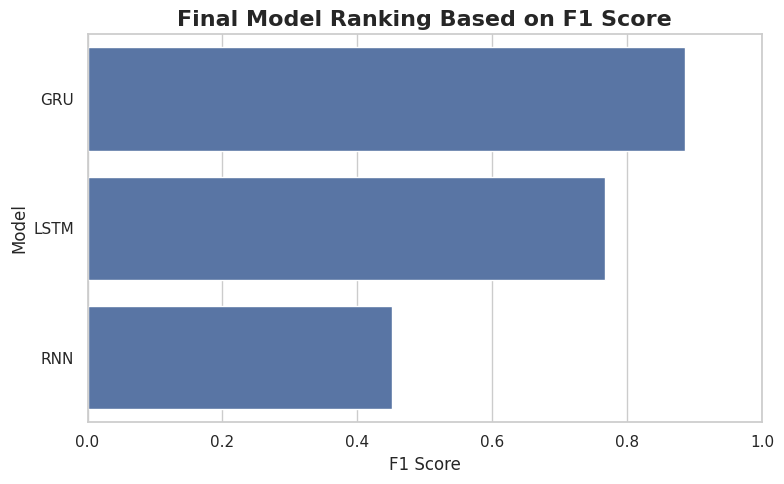

Results saved as rnn_lstm_gru_results.csv


In [34]:
best_model_row = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("Best model based on F1-score:")
print(
    best_model_row["Model"]
)

print(
    "\nF1-score:",
    round(best_model_row["F1 Score"], 4)
)

print(
    "Accuracy:",
    round(best_model_row["Accuracy"], 4)
)
ranking = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time",
        "Parameters"
    ]
].sort_values(
    by="F1 Score",
    ascending=False
)

ranking.round(4)
plt.figure(figsize=(8, 5))

ranking_plot = ranking.copy()

sns.barplot(
    data=ranking_plot,
    x="F1 Score",
    y="Model"
)

plt.title(
    "Final Model Ranking Based on F1 Score",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("F1 Score")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()
results_df.to_csv(
    "rnn_lstm_gru_results.csv",
    index=False
)

print("Results saved as rnn_lstm_gru_results.csv")